# **MÓDULO 18 - Pratique**
# Regressão Linear

Agora que aprendemos como aplicar a regressão linear simples e múltipla, colocaremos em prática os conceitos vistos na aula.

Temos aqui uma base de imóveis para alugar, precisamos desenvolver um modelo de regressão linear múltipla para conseguir prever o preço de imóveis dadas as variáveis independentes do nosso modelo.

**Atenção! Esse é seu primeiro modelo, caso tenha dificuldade conte com a ajuda da tutoria**

Você notará que alguns códigos já estão presentes para facilitar a construção de vocês.

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv("ALUGUEL_MOD12.csv", delimiter=';')

df.head(10)

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
0,480,295,48,2,2,1,1
1,500,0,50,1,2,1,1
2,500,0,40,1,2,1,1
3,500,36,45,1,2,1,0
4,500,0,30,1,1,0,0
5,500,380,66,2,1,0,1
6,550,100,48,2,2,1,1
7,600,110,46,2,2,1,1
8,600,100,49,2,2,1,1
9,600,325,50,2,2,1,1


Legenda dos dados:

*   **Valor_Aluguel** : valor Total pago no aluguel

*   **Valor_Condominio** : Valor do Condomínio.

*   **Metragem** : Metragem do Apartamento.

*   **N_Quartos** : Número de Quartos do Imóvel.

*   **N_banheiros** : Número de banheiros.

*   **N_Suites** : Número de Suítes.

*   **N_Vagas** : Número de Vagas.

# 1 - Realize a primeira etapa de pré processamento dos dados.

A) Verifique os tipos de dados.


B) Verifique os dados faltantes, se houver dados faltantes faça a substituição ou remoção justificando sua escolha.

In [3]:
df.dtypes

Valor_Aluguel       int64
Valor_Condominio    int64
Metragem            int64
N_Quartos           int64
N_banheiros         int64
N_Suites            int64
N_Vagas             int64
dtype: object

In [4]:
df.isnull().sum()

Valor_Aluguel       0
Valor_Condominio    0
Metragem            0
N_Quartos           0
N_banheiros         0
N_Suites            0
N_Vagas             0
dtype: int64

# 2 - Realize a segunda etapa de pré processamento dos dados.

A) Utilize a função describe para identificarmos outliers e verificarmos a distribuição dos dados.


B) Caso note uma variável que te pareça conter outliers realiza a análise e tratamento desses dados, justificando a escolha do método utilizado.

C) Realize a análise bivariada dos dados. Faça uso de pelo menos 3 gráficos e traga insights acerca do analisado.

In [5]:
df.describe()

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
count,7203.000000,7203.000000,7203.000000,7203.000000,7203.000000,7203.000000,7203.00000
mean,2966.596140,811.538109,88.506178,2.300153,2.095932,1.016660,1.44176
std,2948.720385,796.564846,61.567505,0.826615,0.983812,0.874204,0.86993
min,480.000000,0.000000,30.000000,1.000000,1.000000,0.000000,0.00000
25%,1350.000000,395.000000,52.000000,2.000000,2.000000,1.000000,1.00000
50%,2000.000000,592.000000,67.000000,2.000000,2.000000,1.000000,1.00000
75%,3200.000000,980.000000,100.000000,3.000000,2.000000,1.000000,2.00000
max,25000.000000,9500.000000,880.000000,10.000000,8.000000,5.000000,9.00000


In [27]:
(df['Valor_Condominio'] == 0).sum()

np.int64(0)

In [22]:
Q1 = df['Valor_Condominio'].quantile(0.25)
Q3 = df['Valor_Condominio'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

df = df[(df['Valor_Condominio'] >= limite_inferior) & (df['Valor_Condominio'] <= limite_superior)]

mediana_sem_outliers = df['Valor_Condominio'].median()

df.loc[
    (df['Valor_Condominio'] < 100) | (df['Valor_Condominio'] > limite_superior),
    'Valor_Condominio'
] = mediana_sem_outliers

print(limite_inferior, limite_superior)

102.5 962.5


In [23]:
fig = px.box(df, y='Valor_Condominio', title='BoxPlot de Valor_Condominio')
fig.show()

In [28]:
df.head()

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
0,480,295,48,2,2,1,1
5,500,380,66,2,1,0,1
7,600,110,46,2,2,1,1
9,600,325,50,2,2,1,1
11,600,600,35,1,2,1,1


In [26]:
print("Porcentagem de registros onde 'balanco' == 554:",
      (len(df[df['Valor_Condominio'] == 554]) / len(df)) * 100)

Porcentagem de registros onde 'balanco' == 554: 19.407149084568438


Utilizei o método IQR para realizar o tratamento dos outliers, pois havia uma distância grande entre os valores, logo optei pelo IQR pois ele faz o cálculo da dispersão com base nos quartis (Q1 e Q3). Assim, ele faz a susbstituição de valores pequenos como 0, e de valores muito altos. E observa-se no gráfico boxplot, que mesmo realizando o tratamento desses dados, ainda há alguns valores indicados como outliers, entretanto resolvi mante-los, já que não impactam nossa base de dados de modo significativo.

In [29]:
media_metragem_aluguel = df.groupby('Metragem')['Valor_Aluguel'].mean().reset_index()

fig = px.line(media_metragem_aluguel, x='Metragem', y='Valor_Aluguel',
            title='Relação entre Metragem e Média de Aluguel',
            labels={'Metragem': 'Metragem', 'Valor_Aluguel': 'Média de Valor_Aluguel'})

fig.show()

Como nossa base de dados tem valores bastante diferentes, observa-se que o gráfico não está 'simétrico', entretanto observa-se que há uma tendencia de que quanto maior a metragem, maior será o aluguem do imóvel, o que faz total sentido. Porem, como dito anteriormente, isso não se aplica a todos os imóveis pelo número grande da base de dados. 

In [30]:
mediana = df.groupby('N_Suites')['Valor_Aluguel'].median().reset_index()

fig = px.bar(mediana, x='N_Suites', y='Valor_Aluguel',
            title='Média Valor_Aluguel pelo N_Suites')
fig.show()

O gráfico mostra que quanto mais suítes em um imóvel, maior o valor de aluguel.

In [31]:
mediana = df.groupby('N_Vagas')['Valor_Aluguel'].median().reset_index()

fig = px.bar(mediana, x='N_Vagas', y='Valor_Aluguel',
            title='Média Valor_Aluguel pelo N_Vagas')
fig.show()

Observa-se no geáfico que quanto menor o valor do aluguem, menores são as vagas para o imóvel. Logo, há uma maior procura por imóveis com baixo valor, enquanto que em condominios com alugueis mais caros, o número de vagas disponíveis é maior.

# 3 - Realize a terceira etapa de pré processamento dos dados.

A) Comece pela correlação, que sabemos ser uma parte importante para nosso pré processamento e análise. Plote o gráfico ou a tabela e indique as variáveis que te parecem mais "fortes" na correlação para nosso modelo.




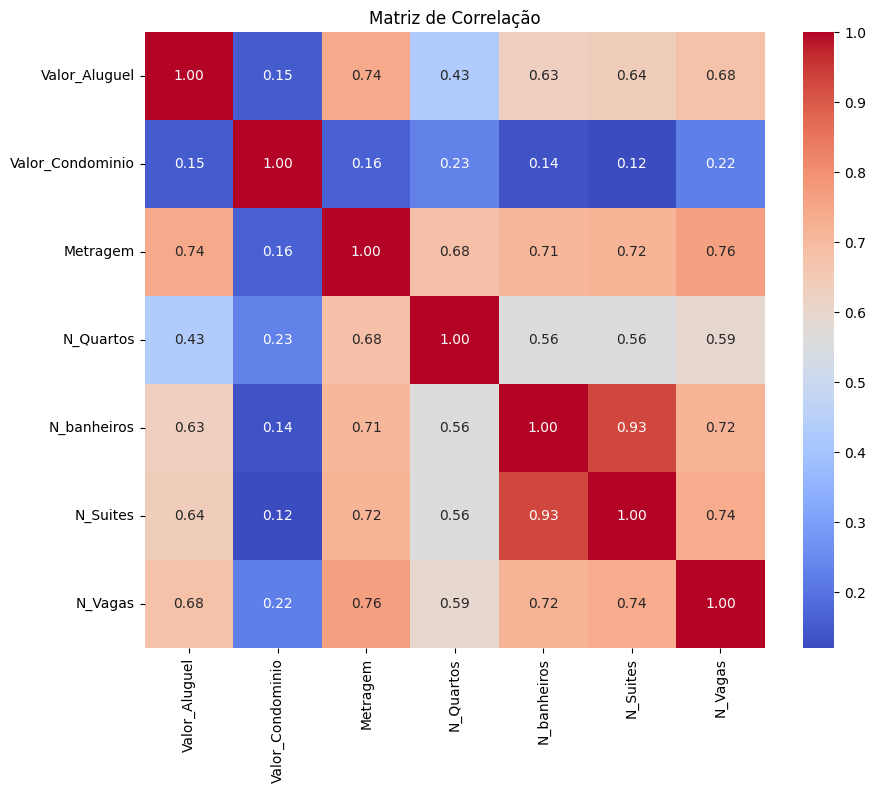

In [32]:
correlation_matrix = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title('Matriz de Correlação')
plt.show()

Variáveis com maior correlação:
- N_Suites com N_Banheiros
- N_Vagas com Metragem 
- Metragem com valor_Aluguel
- N_Vagas com N_Suites
- N_Banheiros com N_Vagas


B) Durante a aula, por nossa base ser pequena e demonstrativa não realizamos a separação de treino e teste, porém para as atividades do dia dia temos que fazer, nesse exercício separe treino e teste.

Lembre-se que primeiro separamos as variaveis dependentes X e depois Y, essa etapa deixarei para vocês abaixo:

In [83]:
X = df.drop('Valor_Aluguel', axis=1) #Separando X - Todas variáveis exceto valor_aluguel
y = df['Valor_Aluguel'] #Separando Y (Apenas variavel valor_aluguel)

In [85]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [86]:
print('Tamanho de X_train:', X_train.shape)
print('Tamanho de X_test:', X_test.shape)
print('Tamanho de y_train:', y_train.shape)
print('Tamanho de y_test:', y_test.shape)

Tamanho de X_train: (5402, 6)
Tamanho de X_test: (1801, 6)
Tamanho de y_train: (5402,)
Tamanho de y_test: (1801,)


Dica: Para separar em treino e teste usamos o train_test_split, como visto nas aulas de pré modelagem.

# 3 - Treine um modelo de regressão Linear simples

A) Vamos utilizar apenas X_train e y_train para rodar um modelo de regressão linea simples e para isso usaremos apenas uma váriavel, a váriavel metragem.

In [91]:
X = X_train[['Metragem']]  # Variável independente (características)
y = y_train  # Variável dependente (rótulo)
# se você deu um nome diferente para x train e y train, altere no código.

In [93]:
#Crie seu modelo aqui, usando LinearRegression e as bases de treino.
regressao = LinearRegression()

regressao.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


B) Plote o intercept_ e coef_ e monte de forma extensa a equação da reta.

In [94]:
regressao.intercept_

np.float64(-103.17820863080169)

Nossa equação seria:  

In [95]:
regressao.coef_

array([34.70818769])

Equação: **regressao = -103.1(METRAGEM) + 34.7**

c) Calcule o R quadrado para o modelo de treinamento. Não esqueça de avaliar e trazer em formato de insight se esse resultado te parece bom ou não.

In [96]:
regressao.score(X,y)

0.5213271756253639

O coeficiente de determinação R2 de 0.52 indica que apenas 52% da variação na variável dependente é explicada pela variável indenpendente. Ou seja, o modelo não é eficaz na previsão dos valores, isso indica que ele precisa de um refinamento e treinamento maior.

D) Plote o gráfico da reta de regressão encontrada e traga insights acerca da dispersão dos pontos e ajuste da reta.

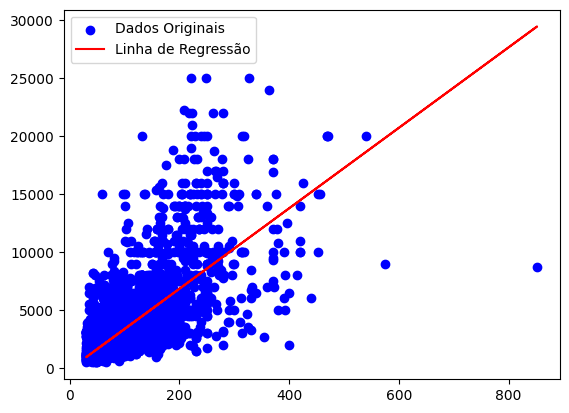

In [ ]:
plt.scatter(X, y, color='blue', label='Dados Originais')

# Plotar a linha de regressão
plt.plot(X, regressao.predict(X), color='red', label='Linha de Regressão')
plt.legend()
plt.show()

O gráfico mostra que há alguns valores próximos da reta, porem o número de valores distantes é maior. O que justifica o valor baixo do R quadrado.

E) Para finalizar vamos aplicar o modelo a base de teste. Essa etapa é nova, então agora vocês avaliaram como o modelo treinado se saiu com a base de testes.
Para isso altere no código abaixo o nome do seu modelo de regressão:

In [99]:
X_test = X_test[['Metragem']]  # Variável independente (características)
y_test = y_test  # Variável dependente (rótulo)

In [101]:
# Usando o modelo treinado para fazer previsões sobre os dados de teste
previsoes = regressao.predict(X_test)

# Avaliando o desempenho do modelo usando métricas como o R²
r2 = regressao.score(X_test, y_test)

print("Coeficiente de Determinação (R²) nos Dados de Teste:", r2)
previsoes

Coeficiente de Determinação (R²) nos Dados de Teste: 0.5651600449476675


array([1632.23117575, 1632.23117575, 1909.89667725, ..., 4998.92538145,
       1736.35573881, 1944.60486494], shape=(1801,))

In [102]:
y

6931    10000
4125     2200
6079     4500
5044     2900
2299     1500
        ...  
3772     2000
5191     3000
5226     3000
5390     3200
860      1100
Name: Valor_Aluguel, Length: 5402, dtype: int64

Se o valor do coeficiente de determinação (R²) para os dados de treinamento for melhor (ou seja, mais próximo de 1) do que o R² para os dados de teste, isso sugere que o modelo está superajustado aos dados de treinamento. Isso significa que o modelo pode estar se ajustando muito bem aos padrões específicos nos dados de treinamento, mas pode não generalizar bem para novos dados que não foram vistos durante o treinamento.

Por outro lado, se o R² para os dados de teste for melhor do que o R² para os dados de treinamento, isso pode ser indicativo de que o modelo está subajustado. Isso significa que o modelo não está se ajustando adequadamente aos padrões nos dados de treinamento e não está capturando a relação entre as variáveis independentes e dependentes de forma eficaz.

Idealmente, gostaríamos que o valor do R² fosse consistente entre os dados de treinamento e teste, indicando que o modelo é capaz de generalizar bem para novos dados. Se houver uma grande diferença entre os valores de R² para os dados de treinamento e teste, isso sugere que o modelo pode precisar de ajustes para melhorar sua capacidade de generalização.

F) Avalie com suas palavras o valor do r quadrado encontrado no treino e no teste.

Escreva sua resposta aqui.

O R² para os dados de teste foi melhor do que o R² para os dados de treinamento, pois o modelo conseguiu generalizar bem para novos dados e o conjunto de teste apresentou um comportamento mais alinhado à tendência linear aprendida.

# 4 - Aplicação do modelo de regressão linear multipla!

A) Vamos refazer os passos anteriores porém para regressão multipla, com todas variáveis dependentes. Comece separando a base treino e teste, dessa vez com todas variáveis para X.

Aqui é só refazer os passos do exercicio 3 porém ao invés de trazer para X apenas metragem, você deve trazer todas colunas (exceto a valor do aluguel).

In [36]:
X = df[['Valor_Condominio', 'Metragem', 'N_Quartos', 'N_banheiros', 'N_Suites', 'N_Vagas']]
y = df['Valor_Aluguel']

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

B) Faça o modelo de regressão linear multipla aplicado só a base de treino.

In [38]:
regressao_multipla = LinearRegression()
regressao_multipla.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [40]:
regressao_multipla.coef_

array([ 5.93850195e-01,  2.81455292e+01, -7.54796485e+02,  3.45335324e+02,
        2.17643590e+02,  7.36926780e+02])

In [41]:
regressao_multipla.intercept_

np.float64(-106.46651810220692)

C) Traga o valor do R quadrado e avalie o valor encontrado.

In [43]:
regressao_multipla.score(X,y)

0.6110042876862927

O coeficiente de determinação R2 de 0.61 indica que 61% da variação na variável dependente é explicada pela variável indenpendente. Ou seja, o modelo é parcialmente eficaz na previsão dos valores, isso indica que ele precisa de alguns refinamentos e treinamento maior.

D) Para finalizar aplique o modelo a base de teste e traga o r quadrado de teste.
Dica: Você pode usar os códigos do exercício anterior.

In [50]:
previsoes = regressao_multipla.predict(X_test)

r2 = regressao_multipla.score(X_test, y_test)

print("Coeficiente de Determinação (R²) nos Dados de Teste:", r2)
previsoes

Coeficiente de Determinação (R²) nos Dados de Teste: 0.547972557467368


array([ 1733.38308847,  1577.25290969,  4702.86186389, ...,
        1222.0542917 , 12637.60733604,  2421.74349703], shape=(1434,))

In [46]:
y

0         480
5         500
7         600
9         600
11        600
        ...  
7198    25000
7199    25000
7200    25000
7201    25000
7202    25000
Name: Valor_Aluguel, Length: 5735, dtype: int64

E) Compare os r quadrados encontrados pela regressão linear e pela regressão múltipla. Qual modelo te parece melhor? Por qual motivo acredita que isso ocorreu?

Digite sua resposta aqui

A regressão múltipla apresentou melhor desempenho por considerar mais variáveis explicativas (R² de 0.61 contra 0.52). Isso indica que a variável dependente é influenciada por múltiplos fatores, e não apenas um, tornando o modelo múltiplo mais acertivo e eficaz.